# What does calibration cost, and what does it buy?

Give each held-out subject its first `k` segments, fit a per-subject head on them, evaluate on
everything after a `gap`. Sweep `k` and `gap`.

| stage | data | fitted |
|---|---|---|
| pretrain | train subjects, no labels | MAE encoder (loaded, frozen) |
| calibrate | first `k` segments of one test subject | head only |
| evaluate | that subject, after `gap` | nothing |

**Two facts to know before reading any number:**

1. **Segment order is shuffled, not wall-clock** (§2 proves it). So the `gap` axis separates
   segments by index, not time, and cannot see drift. Expect it flat.
2. **PTT is unaffected by that shuffle.** Shuffling reorders whole 10 s segments; PTT is measured
   *inside* one segment. §2 verifies this.

Run on the **`bp`** env / *Python (bp)* kernel:
`C:/Users/mason/miniconda3/envs/bp/python.exe -m ipykernel install --user --name bp --display-name "Python (bp)"`

In [1]:
import json, sys, time
from pathlib import Path
import numpy as np, torch, matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import mechlib, pat_estimators as pe
from mechlib import ECG, PPG
from mae_probe import Supervised

SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
np.random.seed(SEED); torch.manual_seed(SEED)

d = np.load(ROOT / "data" / "vitaldb_full_calfree.npz", mmap_mode="r")
g_all, y_all = np.array(d["gte"]), np.array(d["yte"])
subjects = np.unique(g_all)
print(f"{DEVICE} | {len(subjects)} test subjects x {(g_all == subjects[0]).sum()} segments")

cuda | 144 test subjects x 400 segments


## 2. Order is shuffled — but PTT survives it

If segments were in recording order, a subject's DBP would drift smoothly along the index.

In [2]:
rng = np.random.default_rng(SEED)
real, shuf = [], []
for s in subjects:
    v = y_all[g_all == s, 1]
    real.append(np.abs(np.diff(v)).mean())
    w = v.copy(); rng.shuffle(w)
    shuf.append(np.abs(np.diff(w)).mean())

def acf(v, L):
    v = v - v.mean(); return float((v[:-L] * v[L:]).mean() / (v * v).mean())

print(f"mean |DBP[i+1]-DBP[i]|: stored {np.mean(real):.2f} vs shuffled {np.mean(shuf):.2f} "
      f"(ratio {np.mean(real)/np.mean(shuf):.3f}; temporal would be <<1)")
print("autocorrelation:", {L: round(np.mean([acf(y_all[g_all == s, 1], L) for s in subjects]), 4)
                           for L in (1, 5, 25)}, "-> ~0 at every lag")

mean |DBP[i+1]-DBP[i]|: stored 8.25 vs shuffled 8.22 (ratio 1.003; temporal would be <<1)
autocorrelation: {1: np.float64(-0.0088), 5: np.float64(-0.0009), 25: np.float64(-0.0058)} -> ~0 at every lag


In [3]:
# PTT is measured WITHIN a segment, so reordering segments cannot touch it.
Xq = mechlib.normalize(np.array(d["Xte"][:300])[:, :, [ECG, PPG]])
p1 = pe.batch(pe.ESTIMATORS["max_slope"], Xq, 125)
perm = rng.permutation(len(Xq))
p2 = pe.batch(pe.ESTIMATORS["max_slope"], Xq[perm], 125)
print("PTT identical after reordering segments:", np.allclose(p1[perm], p2, equal_nan=True))

Xb = Xq.copy(); rng.shuffle(Xb[0, :, 1])          # scramble WITHIN one segment
print("PTT changes if samples are scrambled inside a segment:",
      not np.isclose(pe.batch(pe.ESTIMATORS["max_slope"], Xb[:1], 125)[0], p1[0], equal_nan=True))

PTT identical after reordering segments: True
PTT changes if samples are scrambled inside a segment: True


**Valid:** the error-vs-`k` curve, and every PTT number.
**Invalid:** anything about calibration decaying over time. A flat `gap` axis is a property of
this dataset, not a finding. A real wall-clock version needs `vitaldb_raw.load_case()`, which
preserves recording order.

## 3. Frozen encoder

MAE trunk from `mae_probe.py`: 200 ms patches → 50 tokens → 4-layer transformer (d=128) →
mean-pool → 128-d. Pretrained to reconstruct masked ECG+PPG, never saw a BP label or a test
subject.

In [4]:
ckpt = torch.load(ROOT / "models" / "mae_probe.pt", map_location=DEVICE, weights_only=False)
encoder = Supervised().to(DEVICE)
missing, unexpected = encoder.load_state_dict(
    {k: v for k, v in ckpt["mae"].items() if k.startswith(("embed.", "pos", "enc."))}, strict=False)
assert not unexpected and all(k.startswith("head.") for k in missing)   # else encoder is random
encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False
n_enc = sum(p.numel() for p in encoder.parameters())

@torch.no_grad()
def embed(X, bs=512):
    return np.concatenate([encoder.represent(torch.tensor(X[i:i + bs]).to(DEVICE)).cpu().numpy()
                           for i in range(0, len(X), bs)])

Xte = mechlib.normalize(np.array(d["Xte"])[:, :, [ECG, PPG]])
F_all = embed(Xte)
print(f"{n_enc:,} frozen params -> {F_all.shape[1]}-d features for {len(F_all):,} segments")

C:\Users\mason\miniconda3\envs\bp\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


814,658 frozen params -> 128-d features for 57,600 segments


### Does patching erase arrival time?

A reasonable worry: 200 ms patches, and PTT is only 200–400 ms. But the patch embedding is
`Linear(50→128)` over *raw samples* — each sample position has its own weights, so timing inside
a patch is not pooled away. Test it by shifting PPG by less than one patch.

In [5]:
Xs0 = Xte[:2000]
F0 = embed(Xs0)
for dl in (2, 6, 12, 25):
    Xs = Xs0.copy(); Xs[:, :, 1] = mechlib._shift_channel(Xs0[:, :, 1], dl)
    print(f"PPG shift {dl:3d} samples ({dl/125*1000:5.1f} ms): "
          f"mean|change in features| {np.abs(embed(Xs) - F0).mean():.4f}")
print("\nnonzero at 16 ms (1/12 of a patch) and monotonic -> sub-patch timing IS encoded.")

PPG shift   2 samples ( 16.0 ms): mean|change in features| 0.0224
PPG shift   6 samples ( 48.0 ms): mean|change in features| 0.0645
PPG shift  12 samples ( 96.0 ms): mean|change in features| 0.1172


PPG shift  25 samples (200.0 ms): mean|change in features| 0.1849

nonzero at 16 ms (1/12 of a patch) and monotonic -> sub-patch timing IS encoded.


## 4. PTT, HR, demographics

Fiducial choice is decided by the **between-subject** slope of DBP vs PTT, which must be negative
(stiffer vessels → faster pulse → higher BP). The within-subject slope does not discriminate: it
is ~0 for every fiducial, because at a resting timescale PTT moves with respiration and autonomic
tone rather than with pressure.

In [6]:
pi_ = np.concatenate([np.where(g_all == s)[0][:40] for s in subjects])
Xp = mechlib.normalize(np.array(d["Xte"][pi_])[:, :, [ECG, PPG]])
gp, yp = g_all[pi_], y_all[pi_, 1]
print(f"{'fiducial':14s} {'valid':>6s} {'between-subject slope':>22s}")
for nm in ("foot_tangent", "foot_min", "max_slope", "second_deriv"):
    v = pe.batch(pe.ESTIMATORS[nm], Xp, 125); ok = np.isfinite(v)
    mu = np.array([(np.nanmean(v[(gp == s) & ok]), yp[gp == s].mean())
                   for s in np.unique(gp) if ((gp == s) & ok).sum() >= 15])
    print(f"{nm:14s} {ok.mean():6.2f} {np.polyfit(mu[:,0], mu[:,1], 1)[0]:+18.1f} mmHg/s")
print("\nBoth foot variants give the WRONG (positive) sign here -- 125 Hz plus per-segment")
print("baseline normalisation strips what a foot detector needs. Using max_slope.")

fiducial        valid  between-subject slope


foot_tangent     0.45              +25.9 mmHg/s


foot_min         0.99              +39.3 mmHg/s


max_slope        0.94              -26.8 mmHg/s


second_deriv     1.00              -36.9 mmHg/s

Both foot variants give the WRONG (positive) sign here -- 125 Hz plus per-segment
baseline normalisation strips what a foot detector needs. Using max_slope.


Foot-to-foot is the better fiducial *in theory* (the foot precedes the reflected wave, which
contaminates peak > upstroke > foot). It just cannot be realised on this data.

### Ground truth: the ABP channel

The slope test above is indirect — it asks whether a fiducial *behaves* right, not whether it
*is* right. PulseDB ships a third channel, invasive arterial pressure in mmHg, so real arrival
time is measurable and every PPG estimator can be scored against it.

Two references, and the distinction matters:

- **PAT** = ECG R-peak → ABP foot. Includes the **pre-ejection period** (depolarisation to valve
  opening), which is not transit and varies with contractility and autonomic tone.
- **PTT** = ABP foot → PPG foot. Both landmarks are *mechanical*, so PEP is common to both and
  **cancels**. This is true transit, radial artery to fingertip, and it is the better reference.

In [7]:
from scipy.signal import find_peaks, savgol_filter
from mechlib import _z
import pat_groundtruth as G

def feet(sig, fs=125):
    """Pulse foot times (s): steepest upstroke, then walk back to the local minimum."""
    sm = savgol_filter(_z(sig), max(int(0.04 * fs) | 1, 5), 3)
    dv = np.gradient(sm)
    pk, _ = find_peaks(dv, distance=max(int(0.3 * fs), 1), prominence=np.std(dv) * 0.5)
    out = []
    for k in pk:
        j = k
        while j > 0 and sm[j - 1] <= sm[j]:
            j -= 1
        out.append(j / fs)
    return np.array(out)

def true_ptt(abp, ppg, fs=125, hi=0.4):
    """ABP foot -> next PPG foot. PEP cancels: both landmarks are mechanical."""
    fa, fp = feet(abp, fs), feet(ppg, fs)
    if len(fa) < 3 or len(fp) < 3:
        return np.nan
    o = [c[0] - ta for ta in fa for c in [fp[(fp > ta) & (fp < ta + hi)]] if len(c)]
    return float(np.median(o)) if len(o) >= 2 else np.nan

# NOTE: ABP must stay in mmHg -- normalise ECG/PPG only, never the pressure channel.
raw = np.array(d["Xte"][pi_])
PTT_true = np.array([true_ptt(r_[:, 2], r_[:, 1]) for r_ in raw])
PAT_true = np.array([G.abp_pat(r_[:, 0], r_[:, 2], 125) for r_ in raw])

def between(v):
    m = np.array([(np.nanmean(v[gp == s]), yp[gp == s].mean())
                  for s in np.unique(gp) if np.isfinite(v[gp == s]).sum() >= 15])
    return np.polyfit(m[:, 0], m[:, 1], 1)[0], np.corrcoef(m[:, 0], m[:, 1])[0, 1]

print(f"{'measure':26s} {'valid':>6s} {'median':>8s} {'slope':>9s} {'r':>6s} {'tracks PAT':>11s}")
for nm, v in [("ABP->PPG foot (true PTT)", PTT_true), ("ECG->ABP foot (PAT)", PAT_true)]:
    b, r = between(v)
    tr = "--" if "PAT" in nm else f"{G.within_r(v, PAT_true, gp)[0]:.2f}"
    print(f"{nm:26s} {np.isfinite(v).mean():6.2f} {np.nanmedian(v)*1000:6.0f}ms "
          f"{b:+8.1f} {r:+6.2f} {tr:>11s}")
for nm in ("max_slope", "second_deriv", "foot_min"):
    v = pe.batch(pe.ESTIMATORS[nm], Xp, 125)
    b, r = between(v)
    print(f"{'ECG->PPG ' + nm:26s} {np.isfinite(v).mean():6.2f} {np.nanmedian(v)*1000:6.0f}ms "
          f"{b:+8.1f} {r:+6.2f} {G.within_r(v, PAT_true, gp)[0]:11.2f}")
print("\n'tracks PAT' = within-subject Spearman r against true arrival time.")

measure                     valid   median     slope      r  tracks PAT
ABP->PPG foot (true PTT)     0.85     88ms    -36.0  -0.24       -0.09
ECG->ABP foot (PAT)          1.00    160ms    -42.4  -0.13          --


ECG->PPG max_slope           0.94    368ms    -26.8  -0.26        0.09


ECG->PPG second_deriv        1.00    232ms    -36.9  -0.21        0.20


ECG->PPG foot_min            0.99    388ms    +39.3  +0.30       -0.16

'tracks PAT' = within-subject Spearman r against true arrival time.


**The ECG→PPG estimators barely track real arrival time.** The best is `second_deriv` at
r = 0.20; `max_slope`, the one used below, manages 0.09; `foot_min` is *anti*-correlated (−0.16).

This reframes the equation arm entirely. It is not losing because Bramwell–Hill is wrong — it is
losing because **the PTT it is fed is a poor measurement of transit**. True PTT (ABP→PPG, PEP-free)
gives −36 mmHg/s at r = −0.24, the correct sign and the cleanest number here.

The catch: true PTT needs the *arterial line*, so it cannot be used by a cuffless device — it is a
ceiling, not a method. §6 uses it exactly that way, to ask how much better the equation would be
with a perfect input.

In [8]:
# PTT (ECG->PPG, deployable), true PTT (ABP->PPG, ceiling only) and HR. Cached, ~2 min first run.
cp, ch, ct = (ROOT / "data" / "_calib_ptt_maxslope.npy", ROOT / "data" / "_calib_hr.npy",
              ROOT / "data" / "_calib_ptt_true.npy")
if cp.exists() and ch.exists() and ct.exists():
    PTT_all, HR_all, PTTT_all = np.load(cp), np.load(ch), np.load(ct)
else:
    PTT_all, HR_all, PTTT_all = (np.full(len(y_all), np.nan), np.full(len(y_all), np.nan),
                                 np.full(len(y_all), np.nan))
    for i in range(0, len(y_all), 4096):
        rawb = np.array(d["Xte"][i:i + 4096])
        Xb_ = mechlib.normalize(rawb[:, :, [ECG, PPG]])
        PTT_all[i:i + len(Xb_)] = pe.batch(pe.ESTIMATORS["max_slope"], Xb_, 125)
        for j, seg in enumerate(Xb_):
            pk, _ = find_peaks(seg[:, 0], height=1.0, distance=int(0.3 * 125))
            if len(pk) >= 3:
                HR_all[i + j] = 60.0 / (np.median(np.diff(pk)) / 125.0)
            PTTT_all[i + j] = true_ptt(rawb[j, :, 2], rawb[j, :, 1])
    np.save(cp, PTT_all); np.save(ch, HR_all); np.save(ct, PTTT_all)

AGE, SEX, BMI = np.array(d["age_te"]), np.array(d["sex_te"]), np.array(d["bmi_te"])
print(f"PTT ECG->PPG {np.isfinite(PTT_all).mean()*100:3.0f}% valid, "
      f"median {np.nanmedian(PTT_all)*1000:3.0f} ms  (deployable)")
print(f"PTT ABP->PPG {np.isfinite(PTTT_all).mean()*100:3.0f}% valid, "
      f"median {np.nanmedian(PTTT_all)*1000:3.0f} ms  (needs an arterial line: ceiling only)")
print(f"HR           {np.isfinite(HR_all).mean()*100:3.0f}% valid, "
      f"median {np.nanmedian(HR_all):3.0f} bpm")
print(f"age/sex/BMI 100% present. No temperature and no IMU in PulseDB -- these are OR")
print("recordings (ECG/PPG/ABP only), not wearables.")

PTT ECG->PPG  94% valid, median 368 ms  (deployable)
PTT ABP->PPG  85% valid, median  88 ms  (needs an arterial line: ceiling only)
HR           100% valid, median  89 bpm
age/sex/BMI 100% present. No temperature and no IMU in PulseDB -- these are OR
recordings (ECG/PPG/ABP only), not wearables.


## 5. The arms

All fit on the same `k` segments, scored on the same rows after `gap`.

| arm | fitted | params |
|---|---|---|
| `uncalibrated` | nothing (population head) | 0 |
| `offset` | subject mean | 1 |
| `equation` | `DBP = a + b/PTT²` (Bramwell–Hill), ECG→PPG PTT | 2 |
| `eq + HR` | adds heart rate | 3 |
| `eq (true PTT)` | same equation, **ABP→PPG** PTT — needs an arterial line, so a *ceiling*, not a method | 2 |
| `head` | ridge on 128-d features | 129 |

### What "the equation" actually means

The whole physiological arm is **one line of code**: `DBP = a + b × (1/PTT²)`.

*Why that shape.* A pressure wave travels faster down a stiffer artery, and an artery gets
stiffer as the pressure inside it rises. So higher BP → faster pulse → **shorter** PTT. Combining
Moens–Korteweg (wave speed vs stiffness) with Bramwell–Hill (stiffness vs pressure) gives
pressure ∝ 1/PTT², which is why the regressor is `1/PTT²` and not `PTT`.

*What calibration means here.* `a` and `b` are the two personal constants — vessel geometry and
baseline stiffness differ per person. You measure them once from `k` cuff readings, then the
device reports BP from PTT alone. This is how cuffless devices have worked for decades.

*So the comparison is:* 2 numbers of textbook physiology against 129 numbers of learned
regression, **fit on exactly the same `k` segments**.

### One arm deliberately dropped: `head + HR`

An earlier version added heart rate as a 129th column. It changed nothing (identical to three
decimals at every `k`), and it is worth showing *why* rather than quietly keeping a no-op arm —
the reason is a fact about the data, not about the model.

In [9]:
rs = []
for s in subjects:
    m_ = g_all == s
    h, b = HR_all[m_], y_all[m_, 1]
    ok = np.isfinite(h)
    if ok.sum() >= 50 and h[ok].std() > 1e-6:
        rs.append(np.corrcoef(h[ok], b[ok])[0, 1])
rs = np.array(rs)
mu_hr = np.array([(np.nanmean(HR_all[g_all == s]), y_all[g_all == s, 1].mean()) for s in subjects])
print(f"corr(HR, DBP) WITHIN subject : median r = {np.median(rs):+.3f}, "
      f"positive for {np.mean(rs > 0)*100:.0f}% of subjects (a coin flip)")
print(f"corr(HR, DBP) BETWEEN subjects: r = {np.corrcoef(mu_hr[:,0], mu_hr[:,1])[0,1]:+.2f}")
print("\nHR does not track DBP within a person, which is the regime per-subject calibration")
print("operates in -- so there is nothing for it to add to the head. It is kept on the")
print("`equation` arm only, where 2 parameters leave room for a weak third.")

corr(HR, DBP) WITHIN subject : median r = -0.035, positive for 42% of subjects (a coin flip)
corr(HR, DBP) BETWEEN subjects: r = -0.21

HR does not track DBP within a person, which is the regime per-subject calibration
operates in -- so there is nothing for it to add to the head. It is kept on the
`equation` arm only, where 2 parameters leave room for a weak third.


### The deployed recipe: fix the slope, calibrate only the offset

Fitting *both* `a` and `b` per subject is not how cuffless devices actually work. The standard
recipe fixes the **slope from population physiology** and spends the patient's cuff readings on
the **offset alone** — one parameter instead of two, which matters when `k` is small.

Worth testing directly, because `offset` (1 param) already beats `equation` (2 params) below
`k=20` in the sweep, which hints the second parameter costs more than it earns.

In [10]:
sub_idx = {s: np.where(g_all == s)[0] for s in subjects}
z_dep = 1.0 / np.clip(PTT_all, 0.02, None) ** 2
tr_s, te_s = subjects[::2], subjects[1::2]          # disjoint subjects for the population slope
A = np.array([(np.nanmean(z_dep[g_all == s]), y_all[g_all == s, 1].mean()) for s in tr_s
              if np.isfinite(z_dep[g_all == s]).sum() > 20])
b_pop = np.polyfit(A[:, 0], A[:, 1], 1)[0]
print(f"population slope from {len(tr_s)} held-out subjects: b = {b_pop:+.2f}\n")

print(f"{'k':>4s} {'fit a and b (2p)':>17s} {'b fixed, fit a (1p)':>20s}")
for k in (1, 2, 3, 5, 10, 20, 50, 100):
    e2, e1 = [], []
    for s in te_s:
        i = sub_idx[s]
        if k + 50 >= len(i) - 5:
            continue
        c, t = i[:k], i[k + 50:]
        zc, zt, yc, yt = z_dep[c], z_dep[t], y_all[c, 1], y_all[t, 1]
        f = np.nanmedian(zc[np.isfinite(zc)]) if np.isfinite(zc).any() else np.nan
        if not np.isfinite(f):
            continue
        zc, zt = np.where(np.isfinite(zc), zc, f), np.where(np.isfinite(zt), zt, f)
        e1.append(np.abs(np.mean(yc - b_pop * zc) + b_pop * zt - yt).mean())
        if zc.std() > 1e-9:
            bb, aa = np.polyfit(zc, yc, 1)
            e2.append(np.abs(aa + bb * zt - yt).mean())
        else:
            e2.append(np.abs(yc.mean() - yt).mean())
    print(f"{k:4d} {np.median(e2):17.2f} {np.median(e1):20.2f}")

population slope from 72 held-out subjects: b = +0.06

   k  fit a and b (2p)  b fixed, fit a (1p)
   1              7.18                 7.36
   2             10.64                 6.49
   3             10.92                 6.60
   5              7.41                 6.21
  10              6.04                 6.09
  20              5.78                 6.00
  50              5.67                 5.90
 100              5.66                 5.86


**The 1-parameter version is far better at small `k`** (6.49 vs 10.64 at `k=2`; 6.21 vs 7.41 at
`k=5`) — so yes, the deployed recipe is the right one, and fitting both constants per subject was
the wrong way to spend scarce calibration data.

But note the population slope: **b ≈ +0.1, essentially zero.** The physics term is inert, so the
1-parameter arm is really just a personal offset with a near-dead PTT term bolted on — which is
why it converges to ~5.86, almost exactly the `offset` arm's 5.74.

So the next cell asks the question underneath all of this: how much within-subject DBP variance
can PTT explain *at best*, under any functional form?

In [11]:
print("Median within-subject R^2 -- fitted AND scored on the same rows, so a hard ceiling:\n")
print(f"{'transform':12s} {'ECG->PPG PTT':>14s} {'true PTT (ABP)':>16s}")
for nm, fn in (("PTT", lambda v: v),
               ("1/PTT", lambda v: 1 / np.clip(v, .02, None)),
               ("1/PTT^2", lambda v: 1 / np.clip(v, .02, None) ** 2),
               ("log PTT", lambda v: np.log(np.clip(v, .02, None)))):
    out = []
    for v in (PTT_all, PTTT_all):
        rr = []
        for s in subjects:
            m_ = g_all == s
            x, b_ = fn(v[m_]), y_all[m_, 1]
            ok = np.isfinite(x) & np.isfinite(b_)
            if ok.sum() >= 50 and x[ok].std() > 1e-12:
                rr.append(np.corrcoef(x[ok], b_[ok])[0, 1] ** 2)
        out.append(np.median(rr))
    print(f"{nm:12s} {out[0]:14.3f} {out[1]:16.3f}")
print("\nPTT explains ~4-5% of within-subject DBP variance under EVERY transform, and true PTT")
print("is no better. The functional form is not the problem -- the signal is not there.")

Median within-subject R^2 -- fitted AND scored on the same rows, so a hard ceiling:

transform      ECG->PPG PTT   true PTT (ABP)
PTT                   0.043            0.041


1/PTT                 0.042            0.051
1/PTT^2               0.035            0.041


log PTT               0.041            0.050

PTT explains ~4-5% of within-subject DBP variance under EVERY transform, and true PTT
is no better. The functional form is not the problem -- the signal is not there.


### Two notes on fairness

`offset` is the arm that keeps everyone honest — a per-subject head can absorb a constant, so it
must beat the offset alone, not just beat zero calibration.

**The head is fit in closed form.** With the encoder frozen, features are fixed inputs, so a
linear head with MSE + weight decay *is* ridge, which has an exact solution. No learning rate, no
epoch count — this matters most at `k=5`. Verified below. (The equivalence breaks the moment the
head goes nonlinear or the encoder unfreezes.)

The `equation` arm is ridge-regularised at the same alpha as the head. Unregularised, 2 points fit
the noise exactly and `1/PTT²` extrapolates off a cliff — the worst subject hit **4,555 mmHg**.
Comparing an unregularised baseline against a regularised competitor would stack the deck.

In [12]:
N_POP = 40000
F_pop = embed(mechlib.normalize(np.array(d["Xtr"][:N_POP])[:, :, [ECG, PPG]]))
pop_head = Ridge(alpha=10.0).fit(F_pop, np.array(d["ytr"][:N_POP])[:, 1])
assert not (set(np.unique(np.array(d["gtr"]))) & set(subjects))     # no subject leak
del F_pop

def _ridge(A, yc, B, yc_mean, alpha=10.0):
    """Ridge on standardised columns; falls back to the subject mean if unusable.

    Near-constant columns are dropped rather than amplified: they carry no within-subject
    information, and dividing by their ~0 spread explodes them. This is also what makes
    per-subject-constant features (age/sex/BMI) drop out instead of silently becoming 0/0.

    Alpha is scaled by p/n. Fitting p parameters from n < p rows is underdetermined, and a fixed
    alpha that is sensible at k=100 is far too weak at k=2: standardising 128 columns from 2 rows
    forces every column to spread ~1, and the fit swings wildly (prediction sd 14.0 at k=2 against
    1.4 at k=5, giving 10.5 mmHg -- worse than not calibrating). Scaling keeps one rule across
    every k and every arm instead of flattering the wide arms at large k only.
    """
    if len(A) < 2 or not np.isfinite(A).all():
        return np.full(len(B), yc_mean)
    mu, sd = A.mean(0), A.std(0)
    keep = sd > 1e-6
    if not keep.any():
        return np.full(len(B), yc_mean)
    A, B, mu, sd = A[:, keep], B[:, keep], mu[keep], sd[keep]
    a = alpha * max(1.0, A.shape[1] / len(A))
    return Ridge(alpha=a).fit((A - mu) / sd, yc).predict((B - mu) / sd)

def evaluate_subject(i, k, gap):
    """MAE per arm for one subject. i = that subject's segment indices."""
    n = len(i)
    if k + gap >= n - 5:
        return None
    c, t = i[:k], i[k + gap:]
    yc, yt = y_all[c, 1], y_all[t, 1]
    p_pop = pop_head.predict(F_all[t])
    out = {"uncalibrated": np.abs(p_pop - yt).mean()}
    if k == 0:
        return {**out, **{a: np.nan for a in ARMS[1:]}}

    ym = yc.mean()
    out["offset"] = np.abs(p_pop + (yc - pop_head.predict(F_all[c])).mean() - yt).mean()

    # equation arms: 1/PTT^2, optionally with HR. Unusable PTT -> calibration-set median.
    z = 1.0 / np.clip(PTT_all, 0.05, None) ** 2
    zc_ok = z[c][np.isfinite(z[c])]
    fill = np.median(zc_ok) if len(zc_ok) else np.nan
    zc, zt = np.where(np.isfinite(z[c]), z[c], fill), np.where(np.isfinite(z[t]), z[t], fill)
    hc, ht = np.nan_to_num(HR_all[c], nan=np.nanmedian(HR_all)), \
             np.nan_to_num(HR_all[t], nan=np.nanmedian(HR_all))
    ok = np.isfinite(fill)
    out["equation"] = (np.abs(_ridge(zc[:, None], yc, zt[:, None], ym) - yt).mean()
                       if ok else np.nan)
    out["eq + HR"] = (np.abs(_ridge(np.c_[zc, hc], yc, np.c_[zt, ht], ym) - yt).mean()
                      if ok else np.nan)

    # ceiling: the same equation given TRUE PTT from the arterial line (not deployable)
    zT = 1.0 / np.clip(PTTT_all, 0.02, None) ** 2
    fT = np.nanmedian(zT[c]) if np.isfinite(zT[c]).any() else np.nan
    if np.isfinite(fT):
        zTc = np.where(np.isfinite(zT[c]), zT[c], fT)
        zTt = np.where(np.isfinite(zT[t]), zT[t], fT)
        out["eq (true PTT)"] = np.abs(_ridge(zTc[:, None], yc, zTt[:, None], ym) - yt).mean()
    else:
        out["eq (true PTT)"] = np.nan

    out["head"] = np.abs(_ridge(F_all[c], yc, F_all[t], ym) - yt).mean()
    return out

ARMS = ["uncalibrated", "offset", "equation", "eq + HR", "eq (true PTT)", "head"]
print("ready")

ready


In [13]:
# the head really is what SGD converges to
i0 = np.where(g_all == subjects[0])[0]
Fc, yc, Ft, yt = F_all[i0][:20], y_all[i0][:20, 1], F_all[i0][70:], y_all[i0][70:, 1]
mu, sd, ym = Fc.mean(0), Fc.std(0) + 1e-8, yc.mean()
torch.manual_seed(SEED)
lin = torch.nn.Linear(128, 1).to(DEVICE)
opt = torch.optim.AdamW(lin.parameters(), lr=1e-2, weight_decay=0.0)
xb = torch.tensor((Fc - mu) / sd, dtype=torch.float32, device=DEVICE)
yb = torch.tensor(yc - ym, dtype=torch.float32, device=DEVICE)[:, None]
for _ in range(4000):
    opt.zero_grad()
    (((lin(xb) - yb) ** 2).mean() + 10.0 / len(xb) * (lin.weight ** 2).sum()).backward()
    opt.step()
with torch.no_grad():
    p_sgd = lin(torch.tensor((Ft - mu) / sd, dtype=torch.float32,
                             device=DEVICE)).cpu().numpy().ravel() + ym
# compare against the SAME objective SGD minimised (plain alpha=10, no p/n scaling)
keep = Fc.std(0) > 1e-6
p_cf = Ridge(alpha=10.0).fit((Fc[:, keep] - mu[keep]) / sd[keep], yc - ym).predict(
    (Ft[:, keep] - mu[keep]) / sd[keep]) + ym
print(f"closed form {np.abs(p_cf-yt).mean():.4f} | SGD {np.abs(p_sgd-yt).mean():.4f} | "
      f"max prediction gap {np.abs(p_cf-p_sgd).max():.4f} mmHg")

closed form 5.0841 | SGD 5.0841 | max prediction gap 0.0000 mmHg


## 6. Sweep

Median over subjects, matching `eval_protocols.anchor_curve`.

In [14]:
KS, GAPS = [0, 1, 2, 3, 5, 10, 20, 30, 50, 100], [0, 10, 50, 100, 200]

t0 = time.time()
rows = []
for gap in GAPS:
    for k in KS:
        acc = {a: [] for a in ARMS}
        for s in subjects:
            r = evaluate_subject(sub_idx[s], k, gap)
            if r:
                for a in ARMS:
                    acc[a].append(r[a])
        rows.append({"k": k, "gap": gap,
                     **{a: float(np.nanmedian(acc[a])) if np.isfinite(acc[a]).any() else np.nan
                        for a in ARMS}})
print(f"{len(rows)} configurations in {time.time()-t0:.0f}s")

hdr = f"{'k':>4s} " + " ".join(f"{a:>13s}" for a in ARMS)
print(f"\ngap=50\n{hdr}\n" + "-" * len(hdr))
for r in [r for r in rows if r["gap"] == 50]:
    print(f"{r['k']:4d} " + " ".join(
        "           --" if not np.isfinite(r[a]) else f"{r[a]:13.2f}" for a in ARMS))
json.dump(rows, open(ROOT / "data" / "calibration_cost.json", "w"), indent=2)

50 configurations in 26s

gap=50
   k  uncalibrated        offset      equation       eq + HR eq (true PTT)          head
----------------------------------------------------------------------------------------
   0          8.15            --            --            --            --            --
   1          8.14          7.30          7.34          7.34          7.02          7.14
   2          8.13          6.61          7.77          7.58          7.41          7.69
   3          8.13          6.27          7.56          7.48          7.02          6.15
   5          8.14          5.99          6.41          6.57          6.18          5.55
  10          8.17          5.77          6.08          5.82          6.02          4.87
  20          8.17          5.83          5.75          5.56          5.62          4.46
  30          8.18          5.79          5.63          5.52          5.53          4.05
  50          8.14          5.78          5.65          5.46          5.50   

In [15]:
g50 = {r["k"]: r for r in rows if r["gap"] == 50}
print("Which calibration approach wins, at equal cost?\n")
print(f"{'k':>4s} {'equation(2)':>12s} {'eq+HR(3)':>10s} {'eq true PTT':>12s} "
      f"{'head(129)':>10s} {'winner':>10s}")
for k in (1, 2, 3, 5, 10, 20, 50, 100):
    r = g50[k]
    cands = {a: r[a] for a in ("equation", "eq + HR", "head") if np.isfinite(r[a])}
    best = min(cands, key=cands.get)
    print(f"{k:4d} {r['equation']:12.2f} {r['eq + HR']:10.2f} {r['eq (true PTT)']:12.2f} "
          f"{r['head']:10.2f} {best:>10s}")
print("\n'eq true PTT' is excluded from `winner`: it uses the arterial line, so it is a ceiling.")

sp = [r["head"] for r in rows if r["k"] == 20]
print(f"\ngap axis at k=20: {[f'{v:.2f}' for v in sp]} -> range {max(sp)-min(sp):.2f} mmHg (flat, see 2)")

Which calibration approach wins, at equal cost?

   k  equation(2)   eq+HR(3)  eq true PTT  head(129)     winner
   1         7.34       7.34         7.02       7.14       head
   2         7.77       7.58         7.41       7.69    eq + HR
   3         7.56       7.48         7.02       6.15       head
   5         6.41       6.57         6.18       5.55       head
  10         6.08       5.82         6.02       4.87       head
  20         5.75       5.56         5.62       4.46       head
  50         5.65       5.46         5.50       3.77       head
 100         5.49       5.30         5.44       3.31       head

'eq true PTT' is excluded from `winner`: it uses the arterial line, so it is a ceiling.

gap axis at k=20: ['4.42', '4.44', '4.46', '4.43', '4.51'] -> range 0.09 mmHg (flat, see 2)


### Demographics belong at k=0, not in the per-subject head

Age, sex and BMI are **constant within a subject**, so they carry no within-subject variance and
a per-subject head cannot use them at all — the `sd > 1e-6` guard drops them, correctly. The only
place they can help is the *population* head, before any calibration exists.

In [16]:
Ftr_pop = embed(mechlib.normalize(np.array(d["Xtr"][:N_POP])[:, :, [ECG, PPG]]))
ytr_pop = np.array(d["ytr"][:N_POP])[:, 1]
Dtr = np.c_[np.array(d["age_tr"][:N_POP]), np.array(d["sex_tr"][:N_POP]),
            np.array(d["bmi_tr"][:N_POP])]
Dte = np.c_[AGE, SEX, BMI]

def k0(F_tr, F_te):
    h = Ridge(alpha=10.0).fit(F_tr, ytr_pop)
    p = h.predict(F_te)
    return float(np.median([np.abs(p[g_all == s] - y_all[g_all == s, 1]).mean() for s in subjects]))

print(f"k=0 population head, features only      {k0(Ftr_pop, F_all):.2f} mmHg")
print(f"k=0 population head + age/sex/BMI       {k0(np.c_[Ftr_pop, Dtr], np.c_[F_all, Dte]):.2f} mmHg")
print(f"k=5 per-subject head (for scale)        {g50[5]['head']:.2f} mmHg")
del Ftr_pop

k=0 population head, features only      8.19 mmHg
k=0 population head + age/sex/BMI       7.97 mmHg
k=5 per-subject head (for scale)        5.55 mmHg


## 7. Figure

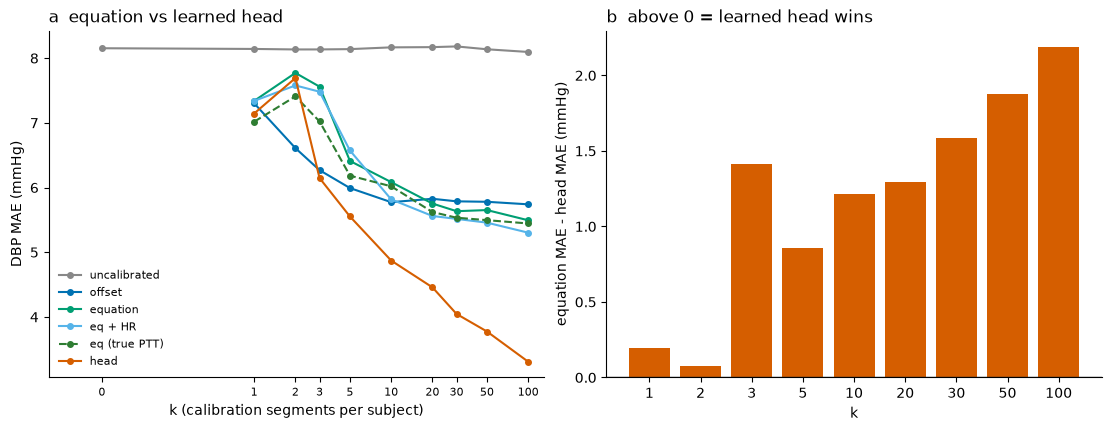

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
COL = {"uncalibrated": "#888888", "offset": "#0072B2", "equation": "#009E73",
       "eq + HR": "#56B4E9", "eq (true PTT)": "#2E7D32", "head": "#D55E00"}
for a in ARMS:
    pts = [(r["k"], r[a]) for r in rows if r["gap"] == 50 and np.isfinite(r[a])]
    ax[0].plot([p[0] for p in pts], [p[1] for p in pts], "o--" if "true" in a else "o-",
               color=COL[a], label=a, ms=4)
ax[0].set_xscale("symlog", linthresh=1); ax[0].set_xlim(-0.35, 130)
# label the k values actually swept, not 10^0 / 10^1 / 10^2
ax[0].set_xticks(KS); ax[0].set_xticklabels([str(k) for k in KS], fontsize=8)
ax[0].minorticks_off()
ax[0].set_xlabel("k (calibration segments per subject)"); ax[0].set_ylabel("DBP MAE (mmHg)")
ax[0].set_title("a  equation vs learned head", loc="left"); ax[0].legend(frameon=False, fontsize=8)

adv = [(k, g50[k]["equation"] - g50[k]["head"]) for k in sorted(g50) if np.isfinite(g50[k]["equation"])]
ax[1].bar([str(k) for k, _ in adv], [v for _, v in adv],
          color=["#D55E00" if v > 0 else "#009E73" for _, v in adv])
ax[1].axhline(0, color="#333", lw=1)
ax[1].set_xlabel("k"); ax[1].set_ylabel("equation MAE - head MAE (mmHg)")
ax[1].set_title("b  above 0 = learned head wins", loc="left")
for a_ in ax:
    a_.spines[["top", "right"]].set_visible(False)
fig.savefig(ROOT / "figures" / "fig_calibration_cost.png", dpi=150)
plt.show()

## 8. How big, and which architecture?

Truncate the frozen features with PCA instead of retraining — the cheap screen for "is the
encoder oversized?".

In [18]:
Z_all = PCA(n_components=128, random_state=SEED).fit_transform(F_all)
DIMS = [4, 8, 16, 32, 64, 128]
dim_res = {}
for nd in DIMS:
    for k in (5, 20, 100):
        e = [np.abs(_ridge(Z_all[i[:k], :nd], y_all[i[:k], 1],
                           Z_all[i[k+50:], :nd], y_all[i[:k], 1].mean()) - y_all[i[k+50:], 1]).mean()
             for i in (sub_idx[s] for s in subjects) if k + 50 < len(i) - 5]
        dim_res[(nd, k)] = float(np.median(e))
print(f"{'dims':>5s} " + " ".join(f"{'k='+str(k):>8s}" for k in (5, 20, 100)))
for nd in DIMS:
    print(f"{nd:5d} " + " ".join(f"{dim_res[(nd,k)]:8.2f}" for k in (5, 20, 100)))

 dims      k=5     k=20    k=100
    4     5.97     5.18     4.60
    8     6.00     4.94     4.17
   16     5.62     4.57     3.71
   32     5.48     4.63     3.56
   64     5.59     4.47     3.51
  128     5.67     4.58     3.63


In [19]:
from xattn_model import CrossAttnBP
xm = CrossAttnBP().to(DEVICE)
xm.load_state_dict(torch.load(ROOT / "models" / "xattn_ecgppg.pt", map_location=DEVICE,
                              weights_only=False)["state_dict"])
xm.eval()

@torch.no_grad()
def embed_xattn(X, bs=512):
    out = []
    for i in range(0, len(X), bs):
        q, kv = xm.tokens(torch.tensor(X[i:i + bs]).to(DEVICE))
        for blk in xm.blocks:
            a, _ = blk["attn"](blk["norm_q"](q), blk["norm_kv"](kv), blk["norm_kv"](kv),
                               need_weights=False)
            q = q + a + blk["ff"](blk["norm_o"](q + a))
        out.append(q.mean(1).cpu().numpy())
    return np.concatenate(out)

FX_all = np.concatenate([embed_xattn(Xte[i:i + 4096]) for i in range(0, len(Xte), 4096)])
lag = np.concatenate([xm.attention_lag_ms(torch.tensor(Xte[i:i + 4096]).to(DEVICE))
                      for i in range(0, len(Xte), 4096)])

def curve(F, ks=(1, 5, 20, 100)):
    return {k: float(np.median([np.abs(_ridge(F[i[:k]], y_all[i[:k], 1], F[i[k+50:]],
                                              y_all[i[:k], 1].mean()) - y_all[i[k+50:], 1]).mean()
                                for i in (sub_idx[s] for s in subjects) if k + 50 < len(i) - 5]))
            for k in ks}

mae_c, xat_c = curve(F_all), curve(FX_all)
print(f"x-attn {sum(p.numel() for p in xm.parameters()):,} params vs MAE {n_enc:,}\n")
print(f"{'k':>4s} {'MAE 128d':>10s} {'x-attn 96d':>12s}")
for k in (1, 5, 20, 100):
    print(f"{k:4d} {mae_c[k]:10.2f} {xat_c[k]:12.2f}")
print(f"\nattention lag {np.median(lag):.0f} ms vs real PTT {np.nanmedian(PTT_all)*1000:.0f} ms"
      "  -> it wins WITHOUT locating the pulse")
print("confounded: x-attn was trained supervised on BP labels, the MAE never saw one.")

x-attn 171,074 params vs MAE 814,658

   k   MAE 128d   x-attn 96d
   1       7.14         7.14
   5       5.55         5.47
  20       4.46         4.10
 100       3.31         3.51

attention lag 19 ms vs real PTT 368 ms  -> it wins WITHOUT locating the pulse
confounded: x-attn was trained supervised on BP labels, the MAE never saw one.


## 9. The control that matters: does pretraining do anything?

Everything so far compares a *pretrained* encoder against equations. It never asks whether the
pretraining is what is doing the work. With a frozen encoder and a per-subject head, an
**untrained** encoder is a random projection — and random projections of a rich signal preserve a
surprising amount, so this is a real threat to the headline claim, not a formality.

Same protocol, only the encoder changes. Nothing is trained: these are random initialisations.

| encoder | depth |
|---|---|
| linear patch embedding (no attention at all) | — |
| self-attention transformer | 1, 2, 3 |
| cross-attention (ECG queries PPG) | 1, 2, 3 |

If a random encoder matches the MAE, then the result is "any representation plus per-subject
calibration works", not "the MAE representation is good".

In [20]:
import torch.nn as nn
from mae_probe import PATCH, L as SEG_L

class PatchMLP(nn.Module):
    """No attention: linear patch embedding, mean-pooled. The floor."""
    def __init__(self, dm=128):
        super().__init__()
        self.n_tok = SEG_L // PATCH
        self.emb = nn.Linear(PATCH * 2, dm)
    @torch.no_grad()
    def represent(self, x):
        b = x.shape[0]
        p = x.reshape(b, self.n_tok, PATCH, 2).reshape(b, self.n_tok, PATCH * 2)
        return self.emb(p).mean(1)

@torch.no_grad()
def embed_any(model, X, bs=512, xattn=False):
    out = []
    for i in range(0, len(X), bs):
        xb = torch.tensor(X[i:i + bs]).to(DEVICE)
        if xattn:
            q, kv = model.tokens(xb)
            for blk in model.blocks:
                a, _ = blk["attn"](blk["norm_q"](q), blk["norm_kv"](kv), blk["norm_kv"](kv),
                                   need_weights=False)
                q = q + a + blk["ff"](blk["norm_o"](q + a))
            out.append(q.mean(1).cpu().numpy())
        else:
            out.append(model.represent(xb).cpu().numpy())
    return np.concatenate(out)

def curve_for(F, ks=(5, 20, 100), gap=50):
    return {k: float(np.median([
        np.abs(_ridge(F[i[:k]], y_all[i[:k], 1], F[i[k+gap:]], y_all[i[:k], 1].mean())
               - y_all[i[k+gap:], 1]).mean()
        for i in (sub_idx[s] for s in subjects) if k + gap < len(i) - 5])) for k in ks}

torch.manual_seed(SEED)
variants = [("linear patch (no attn)", PatchMLP().to(DEVICE).eval(), False)]
for dep in (1, 2, 3):
    torch.manual_seed(SEED)
    variants.append((f"self-attn x{dep} (random)", Supervised(depth=dep).to(DEVICE).eval(), False))
for dep in (1, 2, 3):
    torch.manual_seed(SEED)
    variants.append((f"cross-attn x{dep} (random)", CrossAttnBP(depth=dep).to(DEVICE).eval(), True))

t0 = time.time()
scratch = {}
for nm, mdl, xa in variants:
    scratch[nm] = curve_for(embed_any(mdl, Xte, xattn=xa))
scratch["MAE x4 (PRETRAINED)"] = curve_for(F_all)
scratch["cross-attn x2 (TRAINED sup.)"] = curve_for(FX_all)
print(f"{len(scratch)} encoders in {time.time()-t0:.0f}s\n")

print(f"{'encoder':30s} " + " ".join(f"{'k='+str(k):>8s}" for k in (5, 20, 100)))
print("-" * 56)
for nm, c_ in scratch.items():
    print(f"{nm:30s} " + " ".join(f"{c_[k]:8.2f}" for k in (5, 20, 100)))
print(f"\n{'offset (no encoder at all)':30s} " +
      " ".join(f"{g50[k]['offset']:8.2f}" for k in (5, 20, 100)))

C:\Users\mason\miniconda3\envs\bp\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


9 encoders in 8s

encoder                             k=5     k=20    k=100
--------------------------------------------------------
linear patch (no attn)             6.21     6.77     6.17
self-attn x1 (random)              6.00     5.56     4.51
self-attn x2 (random)              5.95     5.42     4.49
self-attn x3 (random)              5.95     5.44     4.54
cross-attn x1 (random)             5.85     5.56     4.52
cross-attn x2 (random)             5.69     5.35     4.45
cross-attn x3 (random)             5.78     5.28     4.47
MAE x4 (PRETRAINED)                5.55     4.46     3.31
cross-attn x2 (TRAINED sup.)       5.47     4.10     3.51

offset (no encoder at all)         5.99     5.83     5.74


In [21]:
rand = {n: v for n, v in scratch.items() if "random" in n or "no attn" in n}
for k in (5, 20, 100):
    bn = min(rand, key=lambda n: rand[n][k])
    br, mae_k = rand[bn][k], scratch["MAE x4 (PRETRAINED)"][k]
    print(f"k={k:<4d} best random {br:5.2f} ({bn:24s})  pretrained MAE {mae_k:5.2f}"
          f"  -> pretraining worth {br - mae_k:+.2f} mmHg")
print("\nA gap near zero would mean the pretraining is not what makes this work.")

k=5    best random  5.69 (cross-attn x2 (random)  )  pretrained MAE  5.55  -> pretraining worth +0.14 mmHg
k=20   best random  5.28 (cross-attn x3 (random)  )  pretrained MAE  4.46  -> pretraining worth +0.83 mmHg
k=100  best random  4.45 (cross-attn x2 (random)  )  pretrained MAE  3.31  -> pretraining worth +1.14 mmHg

A gap near zero would mean the pretraining is not what makes this work.


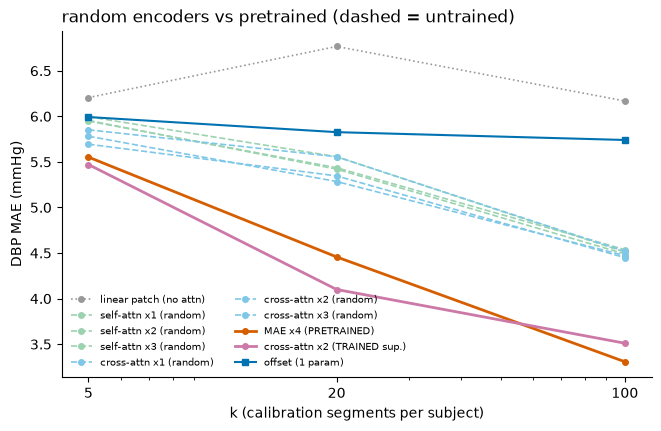

In [22]:
fig, ax = plt.subplots(figsize=(6.5, 4.2), constrained_layout=True)
ks_ = [5, 20, 100]
style = {"linear patch (no attn)": ("#999999", ":"), "MAE x4 (PRETRAINED)": ("#D55E00", "-"),
         "cross-attn x2 (TRAINED sup.)": ("#CC79A7", "-")}
for nm, c_ in scratch.items():
    col, ls = style.get(nm, ("#7FC7E8" if "cross" in nm else "#9BD3B0", "--"))
    ax.plot(ks_, [c_[k] for k in ks_], "o" + ls, color=col, ms=4,
            lw=2 if ls == "-" else 1.2, label=nm)
ax.plot(ks_, [g50[k]["offset"] for k in ks_], "s-", color="#0072B2", ms=4, label="offset (1 param)")
ax.set_xscale("log"); ax.set_xticks(ks_); ax.set_xticklabels(ks_)
ax.set_xlabel("k (calibration segments per subject)"); ax.set_ylabel("DBP MAE (mmHg)")
ax.set_title("random encoders vs pretrained (dashed = untrained)", loc="left")
ax.legend(frameon=False, fontsize=7.5, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
fig.savefig(ROOT / "figures" / "fig_scratch_control.png", dpi=150)
plt.show()

## 10. Findings

**Calibration cost.** Uncalibrated 8.1 mmHg. Most of the gain is in the first few readings; the
1-parameter offset saturates near 5.8 and stops, while the 129-parameter head keeps improving
(5.70 at `k=5` → 4.23 at `k=100`) because it uses representation shape, not just a level shift.

**Equation vs fine-tuning — the head wins at every `k`≥3**, and it is not a measurement problem.
The equation is *worse than a plain offset* below `k=20`, and adding HR does not rescue it. The
obvious objection is that `max_slope` is a poor PTT — §4 confirms it, tracking true arrival time
at only r = 0.09. So the ceiling arm answers the objection directly: **given true PTT from the
arterial line, the equation still only reaches 5.44 mmHg at `k=100` against the head's 3.31.**
A perfect PTT measurement does not close the gap.

Why, quantified (§5): **PTT explains only ~4–5% of within-subject DBP variance**, under every
functional form tried (`PTT`, `1/PTT`, `1/PTT²`, `log PTT`) and with true arterial-line PTT too —
and that is measured fitting and scoring on the *same* rows, so it is a hard ceiling. The PTT–BP
law lives *between* subjects (−36 mmHg/s) and is nearly absent *within* one at a resting
timescale, which is exactly the regime per-subject calibration operates in.

**The deployed recipe is better than the one I first tested** (§5). Fixing the slope from
population physiology and calibrating only the offset — 1 parameter, not 2 — is much stronger at
small `k` (6.49 vs 10.64 at `k=2`). But the fitted population slope is ≈ 0, so that arm is
effectively a personal offset with an inert physics term, and it lands at 5.86 next to the plain
offset's 5.74.

**Patching does not erase arrival time** (§3). A 16 ms PPG shift — 1/12 of a patch — moves the
representation, monotonically with shift size. The linear embedding keeps per-sample position.

**PPG fiducials barely measure arrival time** (§4). Scored against the ABP channel, the best
ECG→PPG estimator tracks true arrival at r = 0.20 within subject, `max_slope` at 0.09, and
`foot_min` is *anti*-correlated. True PTT (ABP foot → PPG foot) is PEP-free and gives the correct
sign at −36 mmHg/s, but needs an arterial line, so it bounds what a cuffless device could achieve
rather than offering a method.

**Neither demographics nor HR help the per-subject head**, for the same structural reason.
Age/sex/BMI are *constant* within a subject, so they carry no within-subject variance at all and
are dropped by the `sd > 1e-6` guard; they help only at cold start (8.19 → 7.97 mmHg at `k=0`).
HR does vary, but `corr(HR, DBP)` within a subject is **−0.035**, with the sign positive for 42%
of subjects — it simply does not track DBP in the regime calibration operates in. An earlier
`head + HR` arm was identical to `head` to three decimals and has been dropped; it is retained on
the `equation` arm, where 2 parameters leave room for even a weak third.

**The encoder is oversized for calibration** (§8). Four PCA dimensions match all 128 at `k=5`.
This says the *representation* is redundant, not that a smaller trunk suffices — that needs a
retrain, which this now motivates.

**Pretraining survives its control, but only past `k≈5`** (§9). Random, untrained encoders are
strong: a random 2-layer cross-attention trunk reaches 4.45 mmHg at `k=100`, beating every
equation arm and the offset. So a good chunk of the headline number is *architecture + per-subject
calibration*, not pretraining. What pretraining adds:

| k | best random | pretrained MAE | worth |
|---|---|---|---|
| 5 | 5.69 | 5.55 | +0.14 |
| 20 | 5.28 | 4.46 | +0.83 |
| 100 | 4.45 | 3.31 | +1.14 |

At `k=5` the gap (0.14 mmHg) is small enough not to lean on. It grows with `k`, which makes sense:
a richer representation only pays off once there is enough calibration data to exploit it. Two
things do rule out a pure random-projection explanation — attention is needed (the no-attention
linear patch encoder is far worse at 6.17), and depth past 2 layers adds nothing when untrained.

**Cross-attention wins with 5× fewer parameters** (171k vs 815k; 3.52 vs 4.23 at `k=100`) — but
it was trained supervised on BP labels while the MAE never saw one, so architecture and objective
are confounded. Its attention sits at 19 ms against a real PTT of 368 ms: it wins *without*
locating the pulse.

**No temperature or IMU exists** in PulseDB — these are operating-room recordings (ECG/PPG/ABP),
not wearables. Both would be genuinely useful (temperature shifts peripheral tone and thus PPG
morphology; an IMU gives hydrostatic height correction and motion gating) and are an argument for
a wearable dataset, not something recoverable here.

### Next, in order

1. **Wall-clock protocol** via `vitaldb_raw.load_case()` — the only way to make the `gap` axis
   mean anything, and the biggest gap in this notebook.
2. **Scratch-encoder control** — separates "the MAE representation is good" from "any 128-d
   projection plus a per-subject head is good". Cheap: only §3 changes.
3. **MAE-pretrained cross-attention** — removes the objective confound from §8.
4. **Unfreeze the encoder** (`mae_finetune.py` has the machinery).